<a href="https://colab.research.google.com/github/July230/AviDetect/blob/develop/AviDetectClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Librerías

In [1]:
!pip install split-folders

In [2]:
import os
import shutil
import random
import splitfolders
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import optimizers
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.math import confusion_matrix

# Path de Google Drive

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


Usaremos el dataset [Drone vs Bird:Aerial Object Classification Dataset](https://www.kaggle.com/datasets/muhammadsaoodsarwar/drone-vs-bird) disponible públicamente [Kaggle](https://www.kaggle.com) bajo la licencia **Apache 2.0**.

Podemos importar el dataset vía kagglehub.

In [4]:
# Download latest version
path = kagglehub.dataset_download("muhammadsaoodsarwar/drone-vs-bird")

print("Path to dataset files:", path)

100%|██████████| 1.59G/1.59G [00:18<00:00, 94.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/muhammadsaoodsarwar/drone-vs-bird/versions/1


El dataset tiene dos carpetas con 4106 imágenes en total:
* bird: 1607 imágenes
* drone: 2499 imágenes

Es necesario hacer el split inicial para obtener train y test. Posteriormente, dividir train en train y validation. Las divisiones comunes para esta división son 70/15/15 u 80/10/10.
Haremos una división de 70% train, 15% validation y 15% test.

In [5]:
def removeDirectories(parentDirectory, directoriesToRemove):
  """
  Remove the directories of a parent directory

  Parameters
  ----------
  parentDirectory : str
    Path to the parent directory you want to clean
  directoriesToRemove : list
    List of the directories to clean

  Returns
  -------
  None
  """
  for directory in directoriesToRemove:
    directoryPath = os.path.join(parentDirectory, directory)
    if os.path.exists(directoryPath):
      shutil.rmtree(directoryPath)
      print(f"Deleted: {directoryPath}")

Tomaremos el dataset de kaggle y el dataset resultado (spliteado) estará en el directorio BirdVSDrone

In [6]:
datasetDirectory = os.path.join(path, "dataset")
outputDirectory = "/content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/BirdVSDrone"

In [7]:
!ls {datasetDirectory}

bird  drone


In [8]:
directoriesToRemove = ["train", "test", "val"]
removeDirectories(outputDirectory, directoriesToRemove)

Deleted: /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/BirdVSDrone/train
Deleted: /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/BirdVSDrone/test
Deleted: /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/BirdVSDrone/val


La librería splitfolders nos permite hacer el split de manera sencilla

In [9]:
splitfolders.ratio(datasetDirectory, output=outputDirectory, seed=42, ratio=(0.7, 0.15, 0.15))

Copying files: 4106 files [00:52, 78.40 files/s]


In [10]:
!ls {outputDirectory}

test  train  val


Dato curioso: La semilla 42 se usa en ocasiones como tradición de programadores y científicos de datos. Aparece de la novela de ciencia ficción de Douglas Adams: *La guía del autoestopista galáctico (1979)*. Aquí, la supercomputadora llamada *Deep though* revela que la respuesta a la gran pregunta de "la vida, el universo y todo lo demás" es 42. Realmente no tiene alguna ventaja computacional.

Verificamos que existan las imagenes

In [11]:
def countImages(directory, directories):
  """
  Count the number of images in a directory

  Parameters
  ----------
  directory : str
    Path to the directory where the images are
  directories : list
    Directories train, test and val that have bird and drone each

  Returns
  -------
  None
  """
  for directory in directories:
    print(f"Images in {directory}:")
    for subdirectory in ["bird", "drone"]:
      totalImages = len(os.listdir(os.path.join(outputDirectory, directory, subdirectory)))
      print(f"{subdirectory}: {totalImages}")

In [12]:
directoriesWithImages = ["train", "test", "val"]
countImages(outputDirectory, directoriesWithImages)

Images in train:
bird: 1124
drone: 1749
Images in test:
bird: 242
drone: 376
Images in val:
bird: 241
drone: 374


Visualizamos las imagenes que hay en train

In [13]:
trainDirectory = os.path.join(outputDirectory, "train")
testDirectory = os.path.join(outputDirectory, "test")
valDirectory = os.path.join(outputDirectory, "val")

In [14]:
def getImages(directory, numImages, seed=42):
  """
  Get the images from a directory and show them

  Parameters
  ----------
  directory : str
    Path to the directory that contains the train set
  numImages : int
    Images to show

  Returns
  -------
  None
  """

  np.random.seed(seed)

  plt.figure(figsize=(10,10))
  images = [i for i in os.listdir(directory) if os.path.isfile(os.path.join(directory, i))]
  np.random.shuffle(images)
  images = images[:numImages]

  for i, image in enumerate(images):
    img = plt.imread(os.path.join(directory, image))
    plt.subplot(4,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(img, cmap=plt.cm.binary)

  plt.show()

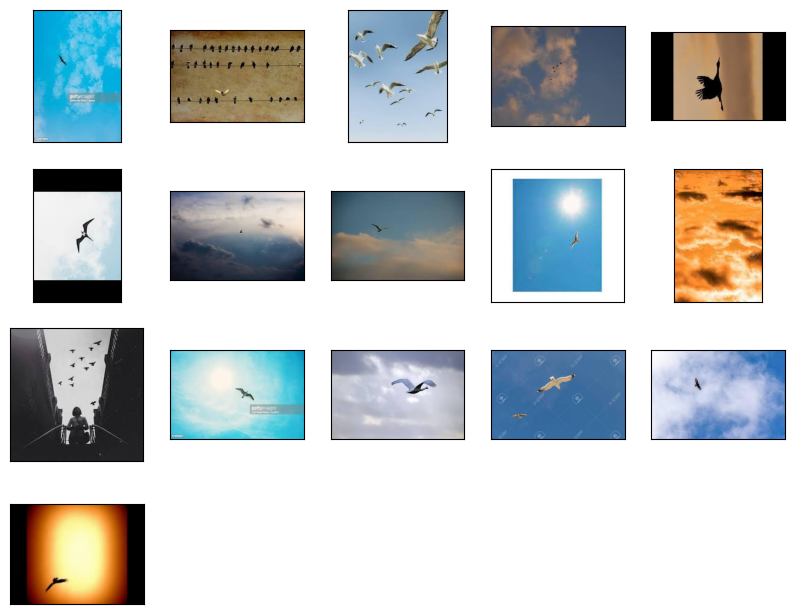

In [16]:
getImages(os.path.join(trainDirectory, "bird"), 16)

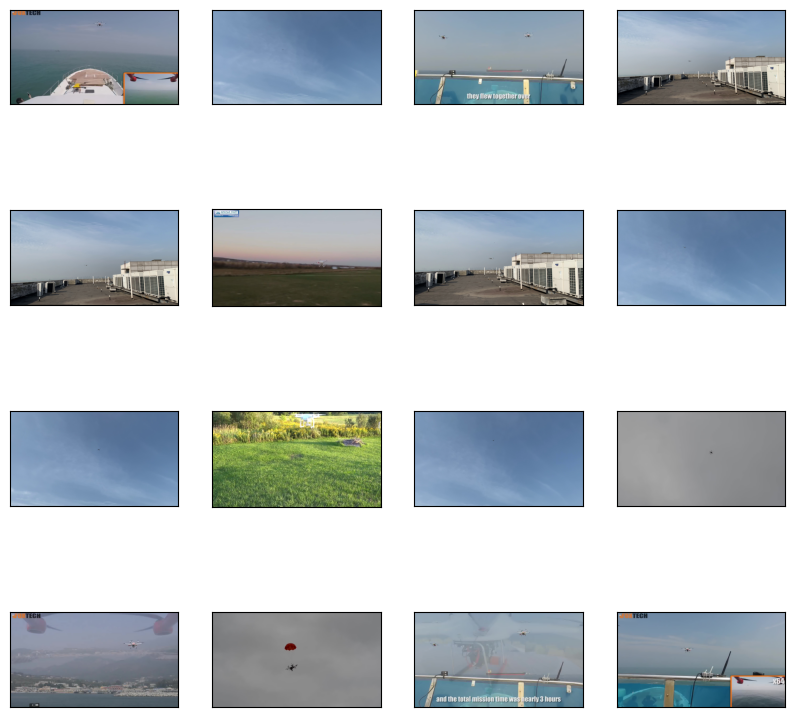

In [15]:
getImages(os.path.join(trainDirectory, "drone"), 16)

# Desbalanceo de clases y data augmentation
El dataset contiene más imágenes de drones que de aves, lo que puede derivar en que el modelo aprenda más a identificar drones que aves.
Para mitigar el desbalanceo de clases, se consideró una técnica de oversampling sobre la clase minoritaria, seguido de data augmentation a todas las clases, siguiendo enfoques similares a los propuestos por Guerrero et al. (2024), donde la aumentación dirigida permitió reducir el sesgo hacia las clases mayoritarias en tareas de clasificación de imágenes.
Es importante destacar que estas alteraciones en el dataset se hacen únicamente en el set de entrenamiento. Los set de validation y test se dejan como están.

Se realizó un oversampling aleatorio. Se calcularon las imágenes faltantes, seleccionando la misma cantidad aleatoriamente y duplicando cada imagen una vez.

In [16]:
def oversample(directory, minorClass, mayorClass, seed=42):
  """
  Selects images randomly and copies in the same directory

  Parameters
  ----------
  directory : str
    Path to the directory that contains the train set
  minorClass : str
    Minority class foldername
  mayorClass : str
    Mayority class foldername
  seed : int
    Random seed

  Returns
  -------
  None
  """

  mayorClassPath = os.path.join(directory, mayorClass)
  minorClassPath = os.path.join(directory, minorClass)

  mayorImages = sorted([i for i in os.listdir(mayorClassPath) if os.path.isfile(os.path.join(mayorClassPath, i))])
  minorImages = sorted([i for i in os.listdir(minorClassPath) if os.path.isfile(os.path.join(minorClassPath, i))])

  lenMayorImages = len(mayorImages)
  lenMinorImages = len(minorImages)
  imagesNeeded = lenMayorImages - lenMinorImages

  print(f"{mayorClass}: {lenMayorImages}")
  print(f"{minorClass}: {lenMinorImages}")
  print(f"Need to generate: {imagesNeeded}")

  if mayorImages == []:
    print(f"{mayorImages} has no images.")
    return

  if minorImages == []:
    print(f"{minorClassPath} has no images.")
    return

  if imagesNeeded <= 0:
    print(f"Dataset already balanced.")
    return

  np.random.seed(seed)
  selectedImages = np.random.choice(minorImages, size=imagesNeeded, replace=True)

  for index, image in enumerate(selectedImages):
    print(f"Copying {index}: {image}")
    sourcePath = os.path.join(minorClassPath, image)
    filename, extension = os.path.splitext(image)
    newFileName = f"{filename}_copy_{index}{extension}"
    destinationPath = os.path.join(minorClassPath, newFileName)
    shutil.copy2(sourcePath, destinationPath)
  print(f"Generated {imagesNeeded} oversampled images in {minorClassPath}")


In [17]:
oversample(trainDirectory, 'bird', 'drone', seed=42)

drone: 1749
bird: 1124
Need to generate: 625
Copying 0: singleBirdinsky352_r180.jpg
Copying 1: singleBirdinsky85_r90.jpg
Copying 2: singleBirdinsky67_r90.jpg
Copying 3: singleBirdinsky102_fli.jpg
Copying 4: singleBirdinsky201_r180.jpg
Copying 5: singleBirdinsky149.jpeg
Copying 6: singleBirdinsky0.jpeg
Copying 7: singleBirdinsky9_r90.jpg
Copying 8: singleBirdinsky358.jpeg
Copying 9: singleBirdinsky102_r90_noise.jpg
Copying 10: singleBirdinsky313_r90.jpg
Copying 11: singleBirdinsky155.jpeg
Copying 12: singleBirdinsky331.jpeg
Copying 13: singleBirdinsky174.jpg
Copying 14: singleBirdinsky395_r180.jpg
Copying 15: singleBirdinsky124.jpg
Copying 16: singleBirdinsky2.jpg
Copying 17: 139.jpg
Copying 18: singleBirdinsky116_r90.jpg
Copying 19: singleBirdinsky307.jpg
Copying 20: singleBirdinsky351.jpg
Copying 21: singleBirdinsky204_r90.jpg
Copying 22: singleBirdinsky80_r180.jpg
Copying 23: singleBirdinsky219.jpg
Copying 24: singleBirdinsky291.jpeg
Copying 25: singleBirdinsky41.jpg
Copying 26: sing

Verificamos que se haya hecho el oversampling en train

In [18]:
countImages(outputDirectory, directoriesWithImages)

Images in train:
bird: 1749
drone: 1749
Images in test:
bird: 242
drone: 376
Images in val:
bird: 241
drone: 374


# Data augmentation
Después de aplicar oversampling, se usa ImageDataGenerator para generar imagenes nuevas en el ram mientras se entrena para no desperdiciar espacio. Se hacen transformaciones verticales y horizontales con un ratio de 0.5.

In [19]:
IMAGEWIDTH = 150
IMAGEHEIGHT = 150
BATCHSIZE = 8


In [20]:
trainDatagen = ImageDataGenerator(
    rescale = 1./255,
    # rotation_range = 10,
    # width_shift_range = 0.2,
    # height_shift_range = 0.2,
    #	shear_range = 0.3,
    # zoom_range = 0.3,
    horizontal_flip = True,
    vertical_flip = True)

Para ello se asigna una fuente base de imágenes a modificar, se toman sólo las del directorio de train. En este caso sólo se toma una imagen y se muestra como se generarían 5 imágenes diferentes.

Found 3495 images belonging to 2 classes.


<Figure size 640x480 with 0 Axes>

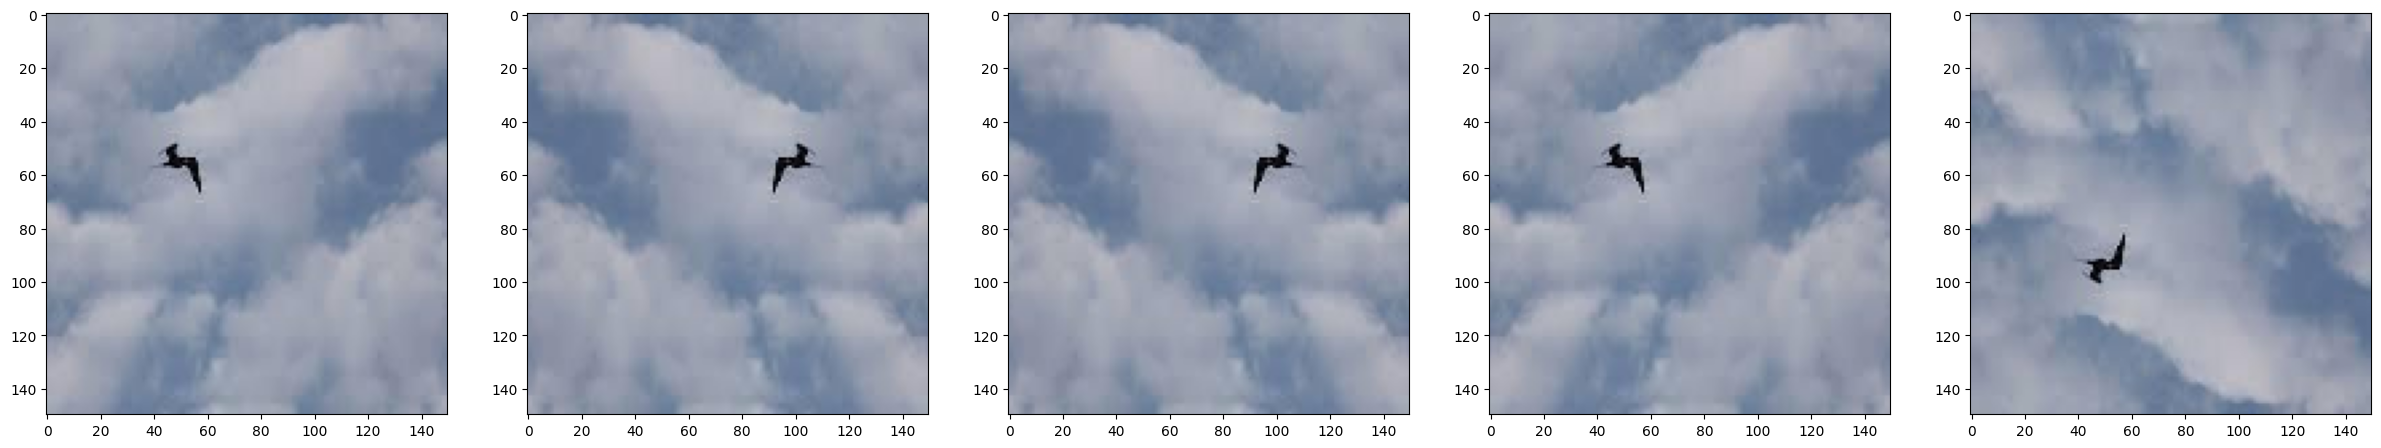

In [21]:
trainGenerator = trainDatagen.flow_from_directory(
    trainDirectory,
    target_size = (IMAGEWIDTH, IMAGEHEIGHT),
    batch_size = BATCHSIZE, # Images that the models gets in each iteration
    class_mode ='binary') # The last neuron of the network must be binary too

plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, 5, figsize=(30, 8))

for i in range(5) :
  axarr[i].imshow(trainGenerator[0][0][0])

(8, 150, 150, 3)
[0. 1. 1. 0. 0. 0. 0. 1.]


<Figure size 640x480 with 0 Axes>

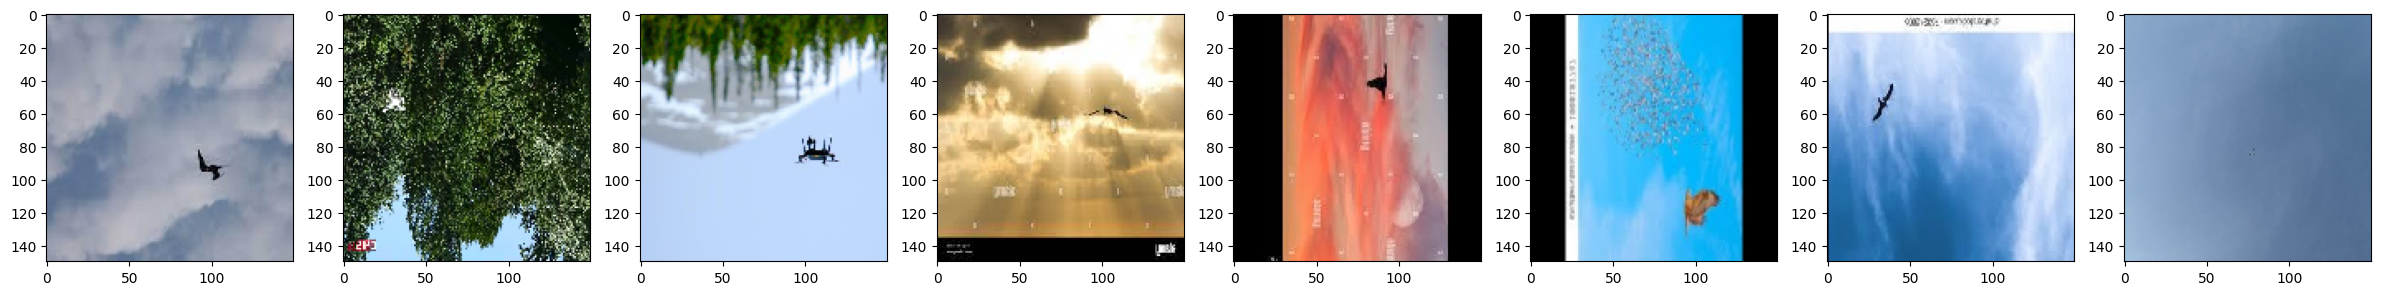

In [22]:
images , labels = trainGenerator[0]

print(images.shape)
print(labels)

plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 4))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

# Primera Red Neuronal Convolutiva (CNN)
Se crea la red neuronal convolutiva. Dado que es un problema de clasificación binaria, se utiliza la función pérdida `binary_crossentropy`.

Con la capa convolutiva se convierten se convierten las características de dos dimensiones (las imágenes) en matrices con las características más singnificativas. Posteriormente se convierte en un vector de una dimensión.

In [23]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation="relu", input_shape = (IMAGEWIDTH,IMAGEHEIGHT,3)))
model.add(layers.Flatten())
model.add(layers.Dense(256,activation="relu"))
model.add(layers.Dense(1,activation="sigmoid")) # Binary on the last neuron for 0 or 1

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 700928)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │   179,437,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 179,438,977 (684.51 MB)

 Trainable params: 179,438,977 (684.51 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    loss="binary_crossentropy",
    optimizer=optimizers.RMSprop(learning_rate=1e-5),
    metrics=["accuracy"])

In [25]:
history = model.fit(trainGenerator, epochs = 4)

accuracy = history.history["accuracy"]
loss = history.history["loss"]

epochs = range(1, len(accuracy)+1)

plt.plot(epochs, accuracy, "bo", label="train accuracy")
plt.title("train accuracy")
plt.legend()

plt.figure()

plt.plot(epochs, loss, "bo", label ="training loss")
plt.title("train loss")
plt.legend()

plt.show()

Epoch 1/4
437/437 ━━━━━━━━━━━━━━━━━━━━ 64s 134ms/step - accuracy: 0.6217 - loss: 0.6843
Epoch 2/4
437/437 ━━━━━━━━━━━━━━━━━━━━ 55s 125ms/step - accuracy: 0.7067 - loss: 0.5740
Epoch 3/4
437/437 ━━━━━━━━━━━━━━━━━━━━ 55s 126ms/step - accuracy: 0.7425 - loss: 0.5170
Epoch 4/4
437/437 ━━━━━━━━━━━━━━━━━━━━ 52s 120ms/step - accuracy: 0.7622 - loss: 0.4855


KeyError: 'acc'

In [26]:
valDatagen = ImageDataGenerator(1./255)
valGenerator = valDatagen.flow_from_directory(
    valDirectory,
    target_size = (IMAGEWIDTH, IMAGEHEIGHT),
    batch_size = BATCHSIZE,
    class_mode = "binary")

valLoss, valAccuracy = model.evaluate(valGenerator, steps = 25)
print("\nval accuracy :\n", valAccuracy)

Found 615 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step - accuracy: 0.8150 - loss: 46.8475

val accuracy :
 0.8149999976158142


Con test sólo queremos lo real, por eso aqui siempre sólo se escala

In [28]:
testDatagen = ImageDataGenerator(1./255)
testGenerator = testDatagen.flow_from_directory(
    testDirectory,
    target_size = (IMAGEWIDTH, IMAGEHEIGHT),
    batch_size = BATCHSIZE,
    class_mode= 'binary')

testLoss, testAccuracy = model.evaluate(testGenerator, steps = 25)
print('\ntest acc :\n', testAccuracy)

Found 618 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - accuracy: 0.8500 - loss: 37.0265

test acc :
 0.8500000238418579


# Comparando resultados

El estado del arte en el problema de clasificación de aves y drones es un acuracy mayor al 90%.

In [29]:
def confusionMatrix(model, setGenerator):
  """
  Creates the confusion matrix based on real and predicted labels

  Parameters
  ----------
  model :
  setGenerator :

  Returns
  -------
  mat : np.ndarray
    Confusion matrix
  """
  predictions = model.predict(setGenerator)
  trueLabels = setGenerator.classes
  predictedClasses = (predictions > 0.5).astype(int).flatten()
  mat = confusion_matrix(trueLabels, predictedClasses)

  print('\t\t', 'label negative', 'label positive')
  print('prediction negative    ', np.array(mat[0][0]), "        ", np.array(mat[0][1]))
  print('prediction positive    ', np.array(mat[1][0]), "         ", np.array(mat[1][1]))

  return mat


def metrics(confusionMatrix):
  """
  Calculates the metrics based on the confusion matrix
  Precision, Recall and F1-score

  Parameters
  ----------
  confusionMatrix : np.ndarray
    Confusion matrix

  Returns
  -------
  None
  """
  truePositives = confusionMatrix[1][1]
  trueNegatives = confusionMatrix[0][0]
  falsePositives = confusionMatrix[0][1]
  falseNegatives = confusionMatrix[1][0]

  precision = truePositives / (truePositives + falsePositives)
  recall = truePositives / (truePositives + falseNegatives)
  f1Score = (precision * recall) / (precision + recall)

  print(f"Precision: {precision}")
  print(f"Recall: {recall}")
  print(f"F1-score: {f1Score}")

## Primer modelo CNN

### Train

In [30]:
print('Model\t\t', 'Train loss\t\t', 'Train Accuracy\t')
print('Original\t ', loss[-1:], '   ', accuracy[-1])

Model		 Train loss		 Train Accuracy	


NameError: name 'loss' is not defined

In [31]:
confusionMatrixTrain = confusionMatrix(model, trainGenerator)

437/437 ━━━━━━━━━━━━━━━━━━━━ 50s 114ms/step
		 label negative label positive
prediction negative     571          1175
prediction positive     577           1172


In [32]:
metrics(confusionMatrixTrain)

Precision: 0.4993608862377503
Recall: 0.6700971983990852
F1-score: 0.28613281250000006


La metrica más baja es la precisión, algo esperado puesto que no acierta correctamente a la mayoría de las instancias de una clase, en este caso, bird. Es por esa razón que el recall es alto, ya que confunde mucho a la clase negativa. Como resultado, el F1-Score es muy bajo, al ser una media armónica de ambas métricas mencionadas, penaliza cuando una de las dos es baja.

### Validation

In [33]:
print('Model\t\t', 'Val loss\t\t', 'Val Accuracy\t')
print('Original\t ', valLoss, '   ', valAccuracy)

Model		 Val loss		 Val Accuracy	
Original	  46.84751510620117     0.8149999976158142


In [34]:
confusionMatrixVal = confusionMatrix(model, valGenerator)

77/77 ━━━━━━━━━━━━━━━━━━━━ 11s 145ms/step
		 label negative label positive
prediction negative     76          165
prediction positive     112           262


In [35]:
metrics(confusionMatrixVal)

Precision: 0.6135831381733021
Recall: 0.7005347593582888
F1-score: 0.32709113607990015


### Test

In [36]:
print('Model\t\t', 'Test loss\t\t', 'Test Accuracy\t')
print('Original\t ', testLoss, '   ', testAccuracy)

Model		 Test loss		 Test Accuracy	
Original	  37.026527404785156     0.8500000238418579


In [37]:
confusionMatrixTest = confusionMatrix(model, testGenerator)

78/78 ━━━━━━━━━━━━━━━━━━━━ 12s 161ms/step
		 label negative label positive
prediction negative     81          161
prediction positive     117           259


In [38]:
metrics(confusionMatrixTest)

Precision: 0.6166666666666667
Recall: 0.6888297872340425
F1-score: 0.32537688442211055
